<a href="https://colab.research.google.com/github/thanu-george/premier-league-eda/blob/main/premier_league_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [13]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "premier-league-matches.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "evangower/premier-league-matches-19922022",
  file_path
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

In [14]:
df.head()

,Season_End_Year,Wk,Date,Home,HomeGoals,AwayGoals,Away,FTR
0,1993,1,1992-08-15,Coventry City,2,1,Middlesbrough,H
1,1993,1,1992-08-15,Leeds United,2,1,Wimbledon,H
2,1993,1,1992-08-15,Sheffield Utd,2,1,Manchester Utd,H
3,1993,1,1992-08-15,Crystal Palace,3,3,Blackburn,D
4,1993,1,1992-08-15,Arsenal,2,4,Norwich City,A


In [15]:
print(df.shape)
print(df.dtypes)

(12026, 8)
Season_End_Year     int64
Wk                  int64
Date               object
Home               object
HomeGoals           int64
AwayGoals           int64
Away               object
FTR                object
dtype: object


In [16]:
df.isnull().sum()

,0
Season_End_Year,0
Wk,0
Date,0
Home,0
HomeGoals,0
AwayGoals,0
Away,0
FTR,0


In [17]:
# decode FTR into readable labels first
df['result']=df['FTR'].map({'H':'Home Win','A':'Away Win', 'D':'Draw'})

#identify class imbalance
print(df['result'].value_counts())
print(df['result'].value_counts(normalize=True).round(3))

result
Home Win    5519
Away Win    3410
Draw        3097
Name: count, dtype: int64
result
Home Win    0.459
Away Win    0.284
Draw        0.258
Name: proportion, dtype: float64


In [18]:
df.describe()

,Season_End_Year,Wk,HomeGoals,AwayGoals
count,12026.000000,12026.000000,12026.000000,12026.000000
mean,2007.713620,19.730501,1.524364,1.142525
std,9.072559,11.123916,1.306417,1.133930
min,1993.000000,1.000000,0.000000,0.000000
25%,2000.000000,10.000000,1.000000,0.000000
50%,2008.000000,20.000000,1.000000,1.000000
75%,2016.000000,29.000000,2.000000,2.000000
max,2023.000000,42.000000,9.000000,9.000000


In [19]:
# encode result so we can run the correlation
le_temp = LabelEncoder()
df['result_encoded'] = le_temp.fit_transform(df['result'])
print(df.corr(numeric_only=True)['result_encoded'].sort_values())

AwayGoals         -0.624102
Season_End_Year   -0.028324
Wk                 0.016795
HomeGoals          0.619380
result_encoded     1.000000
Name: result_encoded, dtype: float64


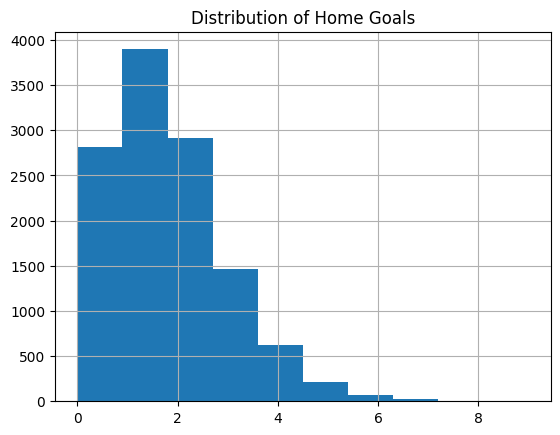

In [20]:
import matplotlib.pyplot as plt
df['HomeGoals'].hist(bins=10)
plt.title('Distribution of Home Goals')
plt.show()

In [21]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [22]:
# build pre-match rolling averages (what we'd actually know before kickoff)
df['home_goals_avg'] = df.groupby('Home')['HomeGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['away_goals_avg'] = df.groupby('Away')['AwayGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['home_conceded_avg'] = df.groupby('Home')['AwayGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['away_conceded_avg'] = df.groupby('Away')['HomeGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df = df.dropna()

In [23]:
le_home   = LabelEncoder()
le_away   = LabelEncoder()
le_result = LabelEncoder()

df['home_encoded']   = le_home.fit_transform(df['Home'])
df['away_encoded']   = le_away.fit_transform(df['Away'])
df['result_encoded'] = le_result.fit_transform(df['result'])

In [24]:
features = ['home_encoded', 'away_encoded',
            'home_goals_avg', 'away_goals_avg',
            'home_conceded_avg', 'away_conceded_avg']

X = df[features]
y = df['result_encoded']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [28]:
# decode numbers back into readable labels
pred_labels = le_result.inverse_transform(predictions[:10])
print(pred_labels)
# ['Away Win' 'Home Win' 'Home Win' ...]

['Away Win' 'Home Win' 'Home Win' 'Home Win' 'Home Win' 'Home Win'
 'Home Win' 'Home Win' 'Home Win' 'Away Win']


In [30]:
print(accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions,
                             target_names=le_result.classes_))

0.4920502092050209
              precision    recall  f1-score   support

    Away Win       0.43      0.31      0.36       654
        Draw       0.00      0.00      0.00       628
    Home Win       0.51      0.88      0.64      1108

    accuracy                           0.49      2390
   macro avg       0.31      0.40      0.34      2390
weighted avg       0.35      0.49      0.40      2390



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Axes: >

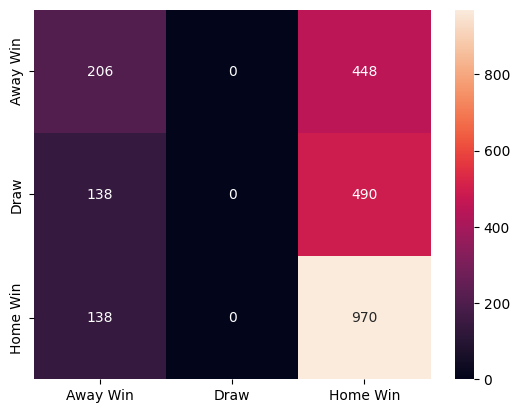

In [31]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'])

In [32]:
from sklearn.ensemble import RandomForestClassifier

# Use 100 trees and limit depth to prevent overfitting
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
# Check the new accuracy and classification report!

In [33]:
print(accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions,
                             target_names=le_result.classes_))

0.4916317991631799
              precision    recall  f1-score   support

    Away Win       0.45      0.32      0.37       654
        Draw       0.24      0.02      0.03       628
    Home Win       0.51      0.86      0.64      1108

    accuracy                           0.49      2390
   macro avg       0.40      0.40      0.35      2390
weighted avg       0.42      0.49      0.41      2390



<Axes: >

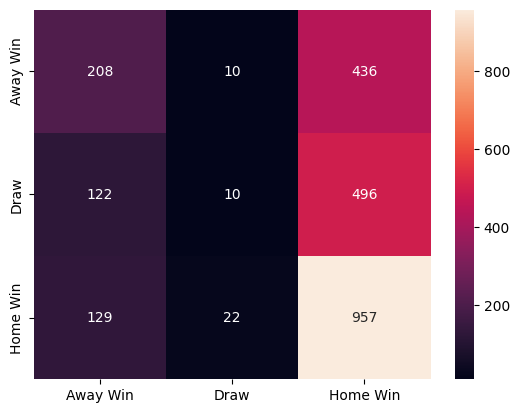

In [34]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Away Win', 'Draw', 'Home Win'],
            yticklabels=['Away Win', 'Draw', 'Home Win'])